# Tutorial 1 — What Is Optimal Transport?

**What you will learn**
- The intuition behind optimal transport (OT) as "moving mass at minimum cost"
- How discrete OT relates to the assignment problem
- The Kantorovich formulation: a linear program over transport plans
- What a transport plan looks like and how to read it
- How to compute your first OT plan with `torchmatch.transport.matrix.solve`

**Prerequisites** — Basic probability (distributions, histograms) and
familiarity with NumPy arrays.  No prior knowledge of OT is assumed.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import torchmatch

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
rng = np.random.default_rng(42)
print("torchmatch", torchmatch.__version__)

torchmatch 1.0.0


## 1  The earth-mover intuition

Imagine two piles of sand on a table.  You want to rearrange the first pile
so it looks like the second.  Moving a grain of sand costs in proportion to the distance it travels.  **Optimal transport** finds the cheapest way to
move sand from the source pile to match the target pile.

In ML contexts:
- "Sand" is probability mass (or feature vectors, or pixels).
- The two piles are probability distributions `a` (source) and `b` (target).
- The cost of moving unit mass from point `x_i` to point `y_j` is given by
  a cost function (often squared Euclidean distance).

## 2  A 1-D example: two histograms

Start with the simplest possible case: two discrete distributions over a
1-D grid.  The source `a` puts mass on the left; the target `b` puts mass
on the right.  The optimal transport plan says exactly how to move mass.

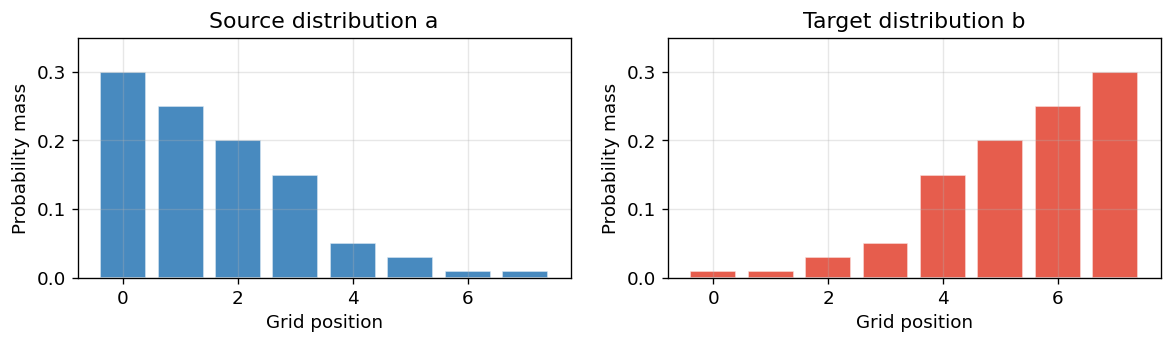

In [2]:
N_BINS = 8  # grid points
grid = np.arange(N_BINS, dtype=np.float32)

# Source: mass concentrated on the left
a = np.array([0.30, 0.25, 0.20, 0.15, 0.05, 0.03, 0.01, 0.01], dtype=np.float32)
# Target: mass concentrated on the right
b = np.array([0.01, 0.01, 0.03, 0.05, 0.15, 0.20, 0.25, 0.30], dtype=np.float32)
assert np.isclose(a.sum(), 1.0) and np.isclose(b.sum(), 1.0)

# Cost matrix: squared Euclidean distance between grid points
C = (grid[:, None] - grid[None, :]) ** 2  # (8, 8)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for ax, dist, title, color in zip(
    axes,
    [a, b],
    ["Source distribution a", "Target distribution b"],
    ["#1a6daf", "#E03520"],
):
    ax.bar(grid, dist, color=color, alpha=0.8, edgecolor="white")
    ax.set_xlabel("Grid position")
    ax.set_ylabel("Probability mass")
    ax.set_title(title)
    ax.set_ylim(0, 0.35)
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### The cost matrix

`C[i, j]` = cost of moving one unit of mass from source bin `i` to target
bin `j`.  Here cost = squared distance, so moving mass far costs more.

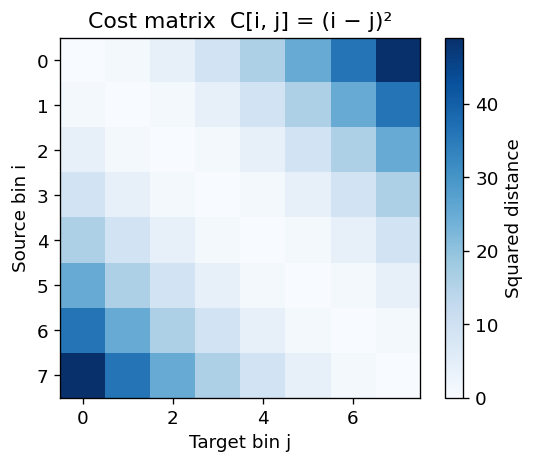

In [3]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(C, cmap="Blues")
ax.set_xlabel("Target bin j")
ax.set_ylabel("Source bin i")
ax.set_title("Cost matrix  C[i, j] = (i − j)²")
plt.colorbar(im, ax=ax, label="Squared distance")
plt.tight_layout()
plt.show()

## 3  The transport plan

A **transport plan** `P` is an `N × M` matrix where `P[i, j]` is the
amount of mass moved from source bin `i` to target bin `j`.  It must
satisfy two constraints:

- **Source marginal**: every row sums to `a[i]`  (all source mass is shipped)
- **Target marginal**: every column sums to `b[j]`  (target receives the right mass)

The **optimal** plan minimises the total transport cost `sum_{ij} P[i,j] * C[i,j]`.

OT is a **generalisation of the assignment problem**: when `a` and `b` are
both uniform (`a[i] = b[j] = 1/N`), the cheapest plan is always a
permutation matrix — exactly the assignment problem solution.

In [4]:
# Solve with torchmatch (default: entropic regularisation, reg=0.1)
cost_t = torch.tensor(C).unsqueeze(0)  # (1, 8, 8) — batch dimension required
a_t = torch.tensor(a).unsqueeze(0)  # (1, 8)
b_t = torch.tensor(b).unsqueeze(0)  # (1, 8)

log_plan = torchmatch.transport.matrix.solve(cost_t, a=a_t, b=b_t, reg=0.01, n_iter=500)
P = log_plan.exp().squeeze(0).numpy()  # (8, 8)

print(f"Plan shape: {P.shape}")
print(f"Row sums (should ≈ a): {P.sum(axis=1).round(3)}")
print(f"Col sums (should ≈ b): {P.sum(axis=0).round(3)}")
transport_cost = (P * C).sum()
print(f"Total transport cost: {transport_cost:.4f}")

Plan shape: (8, 8)
Row sums (should ≈ a): [0.05  0.111 0.089 0.338 0.112 0.18  0.06  0.06 ]
Col sums (should ≈ b): [0.01 0.01 0.03 0.05 0.15 0.2  0.25 0.3 ]
Total transport cost: 4.5030


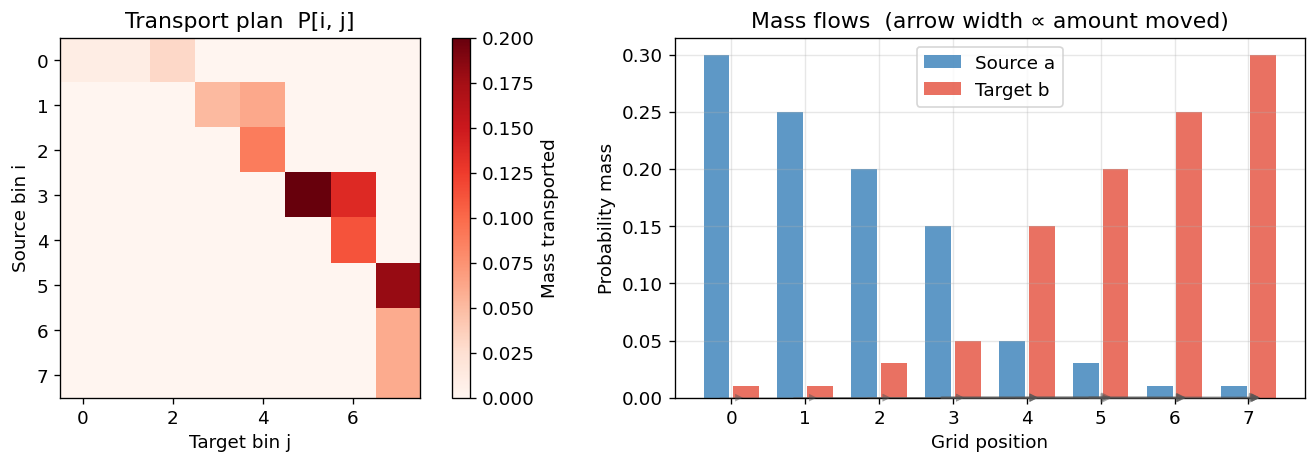

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: the plan as a heatmap
ax = axes[0]
im = ax.imshow(P, cmap="Reds", vmin=0)
ax.set_xlabel("Target bin j")
ax.set_ylabel("Source bin i")
ax.set_title("Transport plan  P[i, j]")
plt.colorbar(im, ax=ax, label="Mass transported")

# Right: the plan as flow arrows
ax = axes[1]
ax.bar(grid - 0.2, a, width=0.35, label="Source a", color="#1a6daf", alpha=0.7)
ax.bar(grid + 0.2, b, width=0.35, label="Target b", color="#E03520", alpha=0.7)

# Draw arrows proportional to mass moved
for i in range(N_BINS):
    for j in range(N_BINS):
        if P[i, j] > 0.005:
            ax.annotate(
                "",
                xy=(j + 0.2, 0),
                xytext=(i - 0.2, 0),
                arrowprops=dict(
                    arrowstyle="-|>",
                    color="#555555",
                    lw=P[i, j] * 8,
                    alpha=0.5,
                ),
            )

ax.set_xlabel("Grid position")
ax.set_ylabel("Probability mass")
ax.set_title("Mass flows  (arrow width ∝ amount moved)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The plan moves mass from the left bins to the right bins in a "diagonal"
pattern: nearby bins exchange more mass than distant ones, matching the
squared-distance cost.

## 4  OT vs assignment: when they coincide

When both distributions are uniform (every bin has weight `1/N`) and the
optimal plan turns out to be a permutation matrix, OT and LAP give the
same answer.

In [6]:
N = 5
a_unif = np.ones(N, dtype=np.float32) / N
b_unif = np.ones(N, dtype=np.float32) / N

# Cost: random non-symmetric
C_lap = rng.random((N, N)).astype(np.float32)
print("Cost matrix:")
print(C_lap.round(3))

# Solve as OT (should recover the same optimal permutation as LAP)
cost_lap = torch.tensor(C_lap).unsqueeze(0)
a_t_u = torch.tensor(a_unif).unsqueeze(0)
b_t_u = torch.tensor(b_unif).unsqueeze(0)

log_plan_unif = torchmatch.transport.matrix.solve(
    cost_lap, a=a_t_u, b=b_t_u, reg=0.001, n_iter=1000
)
P_unif = log_plan_unif.exp().squeeze(0).numpy()

# Also solve as LAP
assignment = torchmatch.assignment.solve(torch.tensor(C_lap))

print("\nOT plan (thresholded at 0.05):")
print((P_unif * N > 0.5).astype(int))  # permutation matrix

print("\nLAP assignment:", assignment.tolist())
print("LAP as permutation matrix:")
perm_matrix = np.zeros((N, N), dtype=int)
for i, j in enumerate(assignment.tolist()):
    perm_matrix[i, j] = 1
print(perm_matrix)

Cost matrix:
[[0.774 0.439 0.859 0.697 0.094]
 [0.976 0.761 0.786 0.128 0.45 ]
 [0.371 0.927 0.644 0.823 0.443]
 [0.227 0.555 0.064 0.828 0.632]
 [0.758 0.355 0.971 0.893 0.778]]

OT plan (thresholded at 0.05):
[[0 0 0 0 1]
 [0 0 0 1 0]
 [1 0 0 0 0]
 [0 0 1 0 0]
 [0 1 0 0 0]]

LAP assignment: [4, 3, 0, 2, 1]
LAP as permutation matrix:
[[0 0 0 0 1]
 [0 0 0 1 0]
 [1 0 0 0 0]
 [0 0 1 0 0]
 [0 1 0 0 0]]


With very small regularisation (`reg=0.001`), the OT plan approaches the
exact LAP solution.  This is the key connection: **assignment is OT between
uniform distributions with zero regularisation**.

## 5  The Wasserstein distance

The **Wasserstein distance** (or earth mover's distance) is the minimum
transport cost:

`W(a, b) = min_P  sum_{ij} P[i, j] * C[i, j]`

Unlike the KL divergence or total variation, the Wasserstein distance respects the geometry of the underlying space: transporting mass farther costs more.  This makes it a meaningful distance for comparing distributions over continuous spaces.

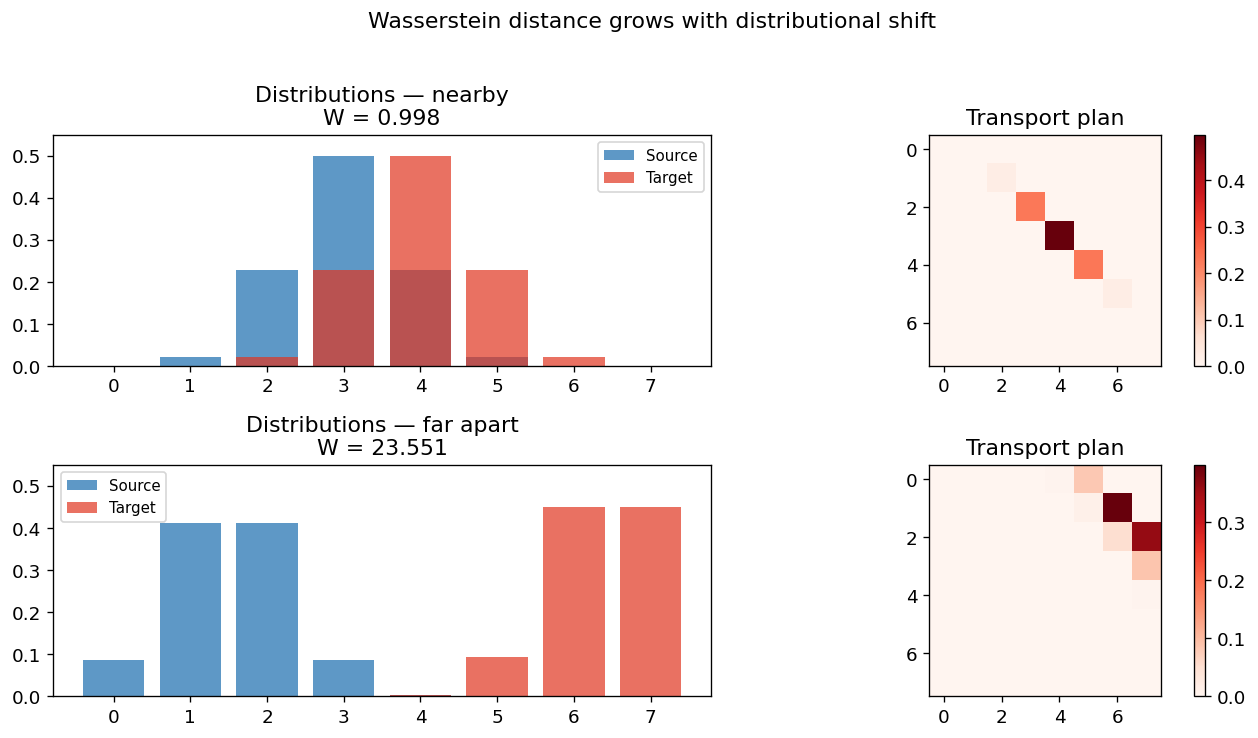

In [7]:
# Compare two pairs of distributions: one nearby, one far apart
def make_gaussian_hist(mean, std, n=8):
    grid = np.arange(n, dtype=np.float32)
    w = np.exp(-0.5 * ((grid - mean) / std) ** 2)
    return (w / w.sum()).astype(np.float32)


pairs = [
    (
        make_gaussian_hist(3.0, 0.8, N_BINS),
        make_gaussian_hist(4.0, 0.8, N_BINS),
        "nearby",
    ),
    (
        make_gaussian_hist(1.5, 0.8, N_BINS),
        make_gaussian_hist(6.5, 0.8, N_BINS),
        "far apart",
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for row, (ai, bi, label) in enumerate(pairs):
    cost_pair = torch.tensor(C).unsqueeze(0)
    log_p = torchmatch.transport.matrix.solve(
        cost_pair,
        a=torch.tensor(ai).unsqueeze(0),
        b=torch.tensor(bi).unsqueeze(0),
        reg=0.02,
        n_iter=300,
    )
    Pi = log_p.exp().squeeze(0).numpy()
    w_dist = (Pi * C).sum()

    axes[row, 0].bar(grid, ai, color="#1a6daf", alpha=0.7, label="Source")
    axes[row, 0].bar(grid, bi, color="#E03520", alpha=0.7, label="Target")
    axes[row, 0].set_title(f"Distributions — {label}\nW = {w_dist:.3f}")
    axes[row, 0].legend(fontsize=9)
    axes[row, 0].set_ylim(0, 0.55)

    im = axes[row, 1].imshow(Pi, cmap="Reds", vmin=0)
    axes[row, 1].set_title("Transport plan")
    plt.colorbar(im, ax=axes[row, 1])

plt.suptitle("Wasserstein distance grows with distributional shift", y=1.02)
plt.tight_layout()
plt.show()

## Summary

- **Optimal transport** finds the minimum-cost way to "move" one
  probability distribution to match another.
- The solution is a **transport plan** `P[i, j]`: the fraction of mass
  moved from source `i` to target `j`.
- OT generalises the assignment problem: with uniform distributions and
  zero regularisation, the optimal plan is a permutation matrix.
- The **Wasserstein distance** measures how far apart two distributions
  are in a way that respects the geometry of the underlying space.

**Next**: [Tutorial 2 — The Sinkhorn Algorithm](02_sinkhorn_algorithm.ipynb)
explains why exact OT is expensive and how entropic regularisation makes
large-scale OT practical.